# APS Failure at Scania Trucks

**Name:** Rymma Won  
**Dataset:** APS Failure and Operational Data for Scania Trucks  
**Source:** Scania CV AB / UCI Machine Learning Repository

---

## Project Overview

I start with dataset understanding and EDA, then preprocess the raw data (missing values, encoding, scaling, PCA), train and tune six machine learning models, and evaluate them using multiple metrics.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV, cross_val_score)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed — install with: pip install xgboost")

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot stylying
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')


##Loading & Verifying Data

In [35]:
# Define file paths for training and test data
TRAIN_PATH = 'aps_failure_training_set.csv'
TEST_PATH  = 'aps_failure_test_set.csv'

df_train_raw = pd.read_csv(TRAIN_PATH, skiprows=20, na_values='na')
df_test_raw  = pd.read_csv(TEST_PATH,  skiprows=20, na_values='na')

#Prints dimensions
print(f"Training set shape : {df_train_raw.shape}")
print(f"Test set shape     : {df_test_raw.shape}")
print()
print("Training class distribution:")
print(df_train_raw['class'].value_counts())
print()
print("Test class distribution:")
print(df_test_raw['class'].value_counts())
print()
print("Sample:")
display(df_train_raw.iloc[:10, :20])

Training set shape : (14070, 171)
Test set shape     : (16000, 171)

Training class distribution:
class
neg    13803
pos      267
Name: count, dtype: int64

Test class distribution:
class
neg    15625
pos      375
Name: count, dtype: int64

Sample:


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,3232.0,1872.0,0.0,0.0,0.0,2668.0,0.0,0.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,1966618.0,1800340.0,131646.0,4588.0,0.0,1974038.0,0.0,226.0
5,neg,38312,NaN,2.130706e+09,218.0,0.0,0.0,0.0,0.0,0.0,0.0,9128.0,701702.0,1462836.0,449716.0,39000.0,660.0,1087760.0,0.0,0.0
6,neg,14,0.0,6.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1202.0,3766.0,1150.0,0.0,0.0,0.0,2094.0,0.0,0.0
7,neg,102960,NaN,2.130706e+09,116.0,0.0,0.0,0.0,0.0,0.0,0.0,2130.0,142462.0,4227340.0,1674278.0,59718.0,876.0,2738458.0,0.0,0.0
8,neg,78696,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,458.0,440704.0,4398806.0,2179182.0,144418.0,808.0,3209768.0,0.0,80.0
9,pos,153204,0.0,1.820000e+02,NaN,0.0,0.0,0.0,0.0,0.0,11804.0,684444.0,326536.0,31586.0,0.0,0.0,0.0,2658638.0,14346.0,0.0


# Exploratory Data Analysis (EDA)


## Class Balance

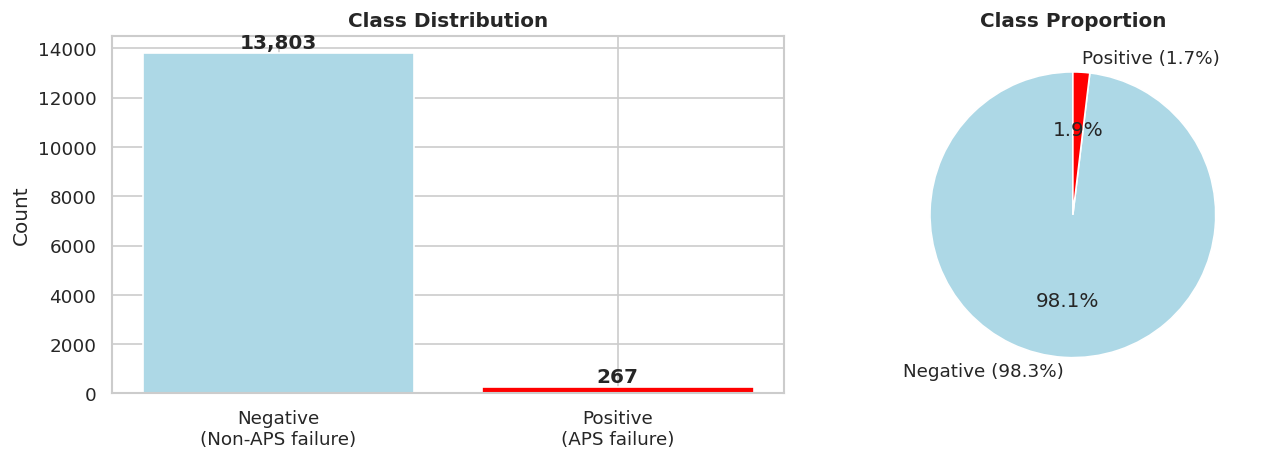


Imbalance ratio: 51.7 negatives per positive.


In [36]:
#Calculate how many negative examples per positive example
class_counts = df_train_raw['class'].value_counts()
imbalance_ratio = class_counts['neg'] / class_counts['pos']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart showing class counts
axes[0].bar(['Negative\n(Non-APS failure)', 'Positive\n(APS failure)'],
            class_counts.values, color=['lightblue', 'red'], edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart shows class proportions with percentages
axes[1].pie(class_counts.values, labels=['Negative (98.3%)', 'Positive (1.7%)'],
            colors=['lightblue', 'red'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {imbalance_ratio:.1f} negatives per positive.")

## Missing Value Analysis

Total missing values: 202,873
Features with >50% missing: 8
Features with >20% missing: 24
Features with any missing : 169
Completely observed features: 1


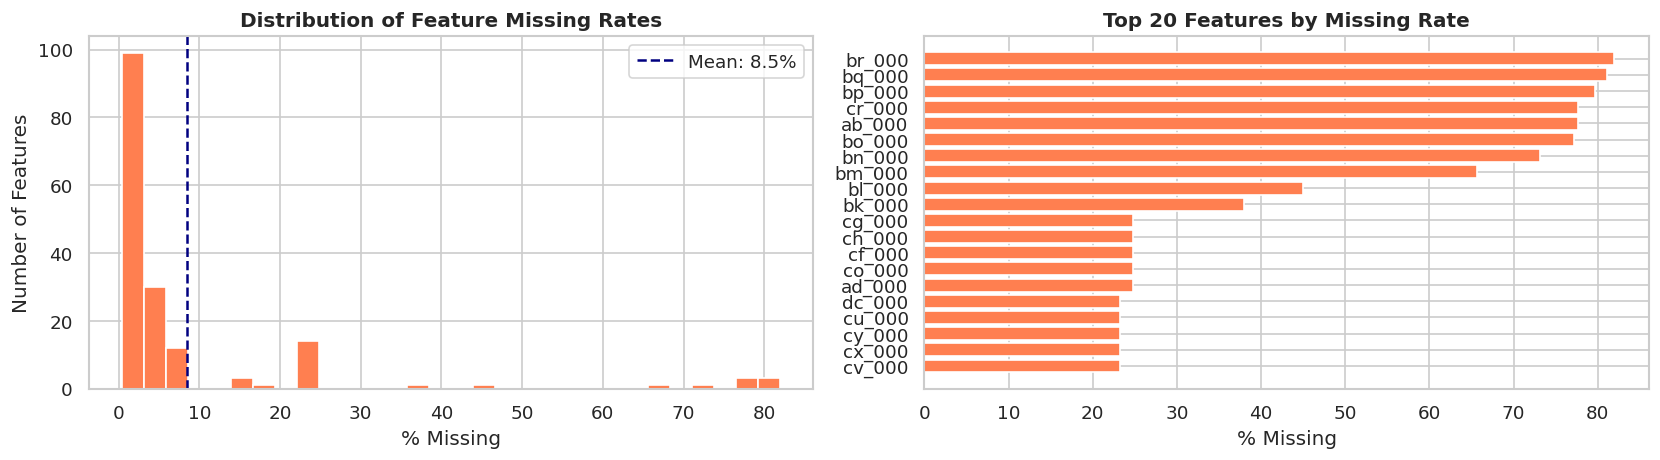

In [37]:
# Calculate missing rates per feature
miss_pct = (df_train_raw.drop('class', axis=1).isnull().sum() / len(df_train_raw) * 100).sort_values(ascending=False)

print(f"Total missing values: {df_train_raw.isnull().sum().sum():,}")
print(f"Features with >50% missing: {(miss_pct > 50).sum()}")
print(f"Features with >20% missing: {(miss_pct > 20).sum()}")
print(f"Features with any missing : {(miss_pct > 0).sum()}")
print(f"Completely observed features: {(miss_pct == 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of missing rates
axes[0].hist(miss_pct[miss_pct > 0], bins=30, color='coral', edgecolor='white')
axes[0].axvline(miss_pct.mean(), color='navy', linestyle='--', label=f'Mean: {miss_pct.mean():.1f}%')
axes[0].set_xlabel('% Missing')
axes[0].set_ylabel('Number of Features')
axes[0].set_title('Distribution of Feature Missing Rates', fontweight='bold')
axes[0].legend()

# Top-20 most missing
top20_miss = miss_pct.head(20)
axes[1].barh(top20_miss.index[::-1], top20_miss.values[::-1], color='coral')
axes[1].set_xlabel('% Missing')
axes[1].set_title('Top 20 Features by Missing Rate', fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Distribution by Class

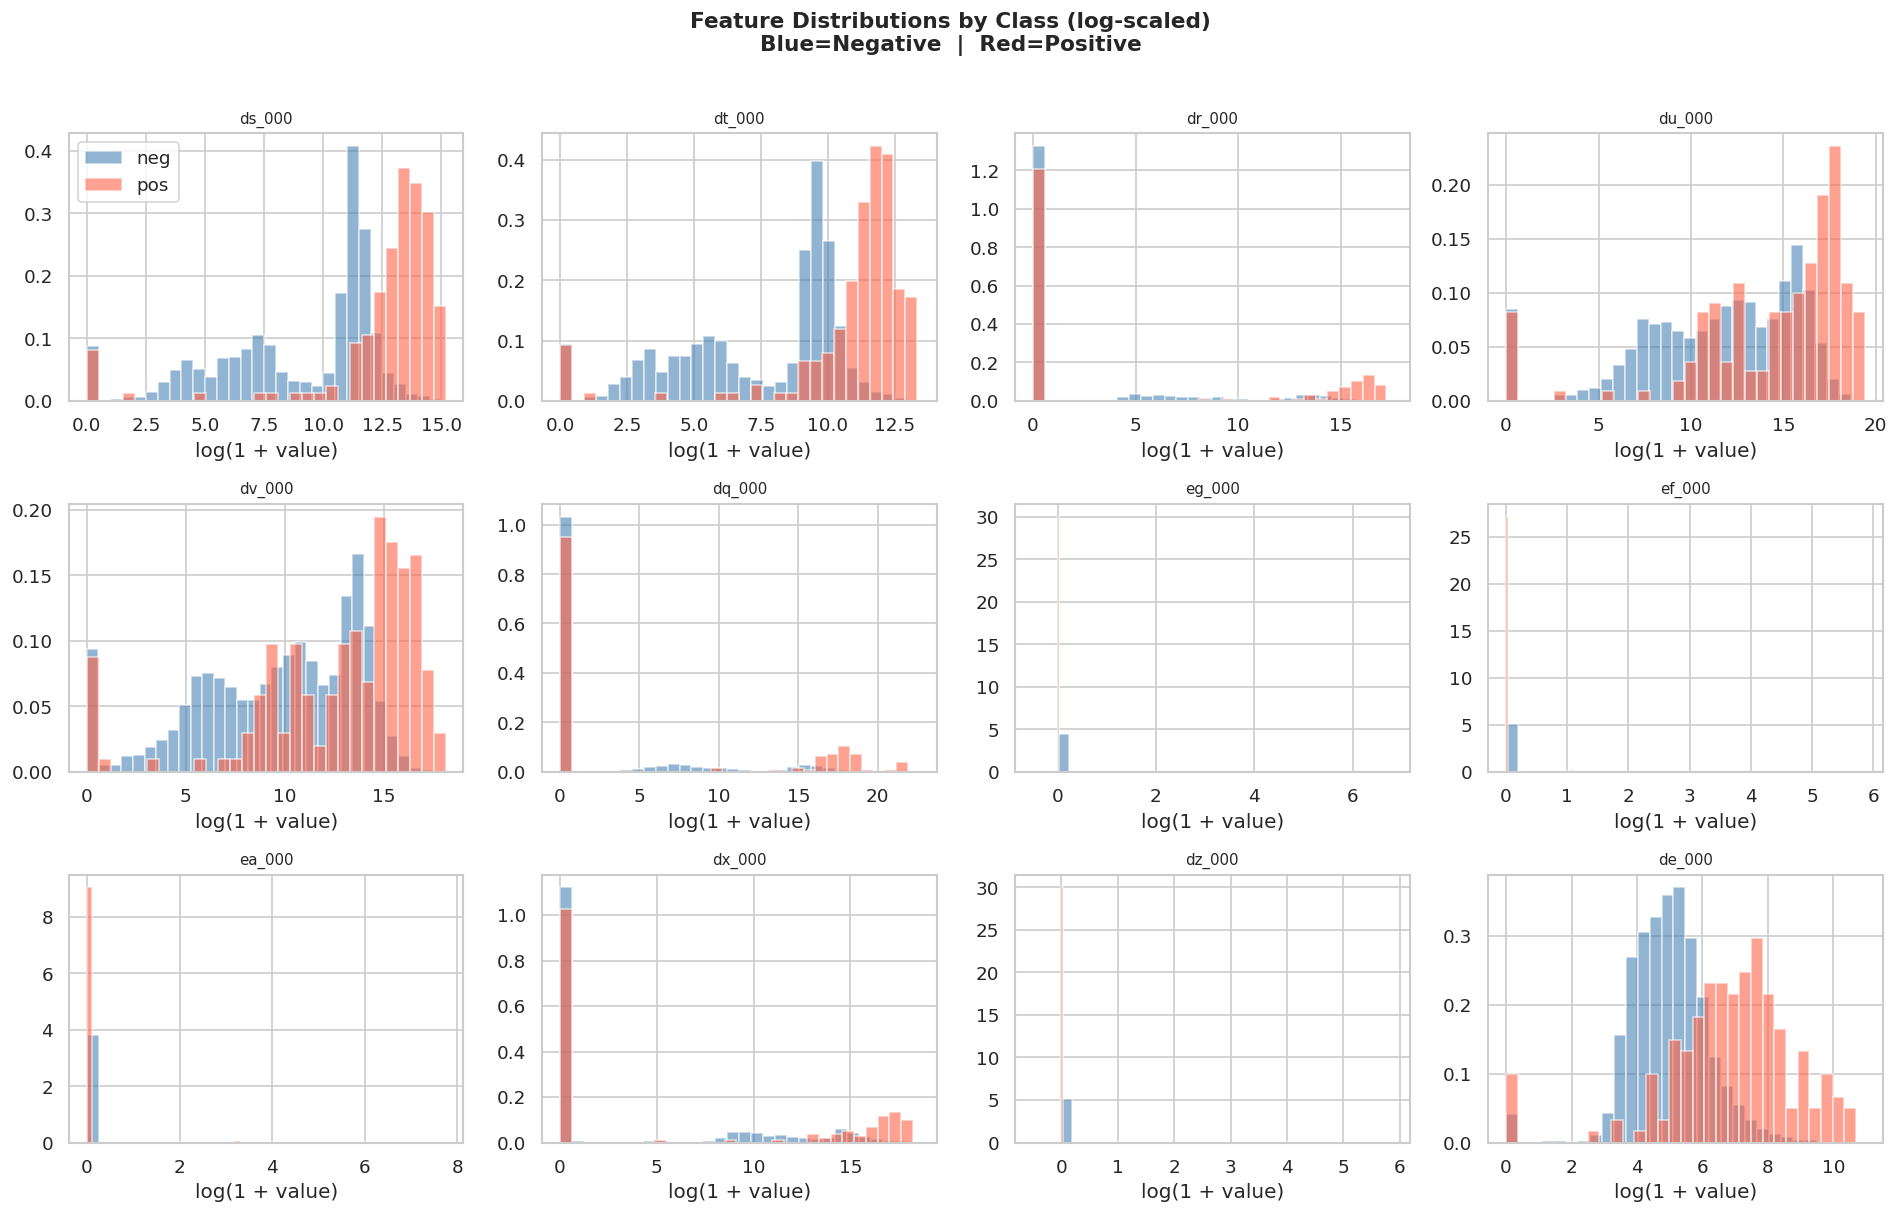

In [38]:
# Selecting 12 features with <5% missing values for visualization
numeric_cols = df_train_raw.drop('class', axis=1).columns
low_miss = miss_pct[miss_pct < 5].index[:12].tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(low_miss):
    for label, color in [('neg', 'steelblue'), ('pos', 'tomato')]:
        subset = df_train_raw[df_train_raw['class'] == label][col].dropna()
        # Log-transform for better visibility, since many features are right-skewed
        vals = np.log1p(subset.clip(lower=0))
        axes[i].hist(vals, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('log(1 + value)')
    if i == 0:
        axes[i].legend()

plt.suptitle('Feature Distributions by Class (log-scaled)\nBlue=Negative  |  Red=Positive',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Statistical Summary & Outlier Detection

In [39]:
# Statistical summary for a representative subset of features
sample_features = low_miss[:8]
print("=== Statistical Summary for positive class ===")
display(df_train_raw[df_train_raw['class'] == 'pos'][sample_features].describe().round(2))

print("\n=== Statistical Summary for negative class ===")
display(df_train_raw[df_train_raw['class'] == 'neg'][sample_features].describe().round(2))

=== Statistical Summary for positive class ===


,ds_000,dt_000,dr_000,du_000,dv_000,dq_000,eg_000,ef_000
count,170.00,170.00,170.00,1.700000e+02,170.00,1.700000e+02,170.0,170.00
mean,915066.00,146077.76,2678029.15,3.097604e+07,5789645.65,9.811627e+07,0.0,0.01
std,846903.03,138002.16,5689063.49,5.255992e+07,10337501.37,4.557290e+08,0.0,0.15
min,0.00,0.00,0.00,0.000000e+00,0.00,0.000000e+00,0.0,0.00
25%,280402.00,50682.00,0.00,2.346850e+05,43571.00,0.000000e+00,0.0,0.00
50%,669898.00,109899.00,0.00,7.840740e+06,1726130.00,0.000000e+00,0.0,0.00
75%,1323514.50,192893.50,1698994.50,4.079964e+07,7161544.50,1.422320e+07,0.0,0.00
max,3931728.00,623562.00,30418516.00,2.668358e+08,74669282.00,3.264652e+09,0.0,2.00



=== Statistical Summary for negative class ===


,ds_000,dt_000,dr_000,du_000,dv_000,dq_000,eg_000,ef_000
count,13215.00,13215.00,13215.00,1.321500e+04,13215.00,1.321600e+04,13216.00,13216.00
mean,79937.75,13864.44,184921.94,3.843155e+06,534212.99,3.100206e+06,0.21,0.07
std,171927.29,27761.69,1314420.31,9.977816e+06,1513769.13,8.820557e+07,8.52,3.44
min,0.00,0.00,0.00,0.000000e+00,0.00,0.000000e+00,0.00,0.00
25%,718.00,156.00,0.00,5.280000e+03,726.00,0.000000e+00,0.00,0.00
50%,47156.00,8360.00,0.00,1.862800e+05,30718.00,0.000000e+00,0.00,0.00
75%,96805.00,17255.00,0.00,3.574630e+06,548896.00,0.000000e+00,0.00,0.00
max,3322022.00,656432.00,39461804.00,2.351036e+08,39487052.00,6.351873e+09,892.00,350.00


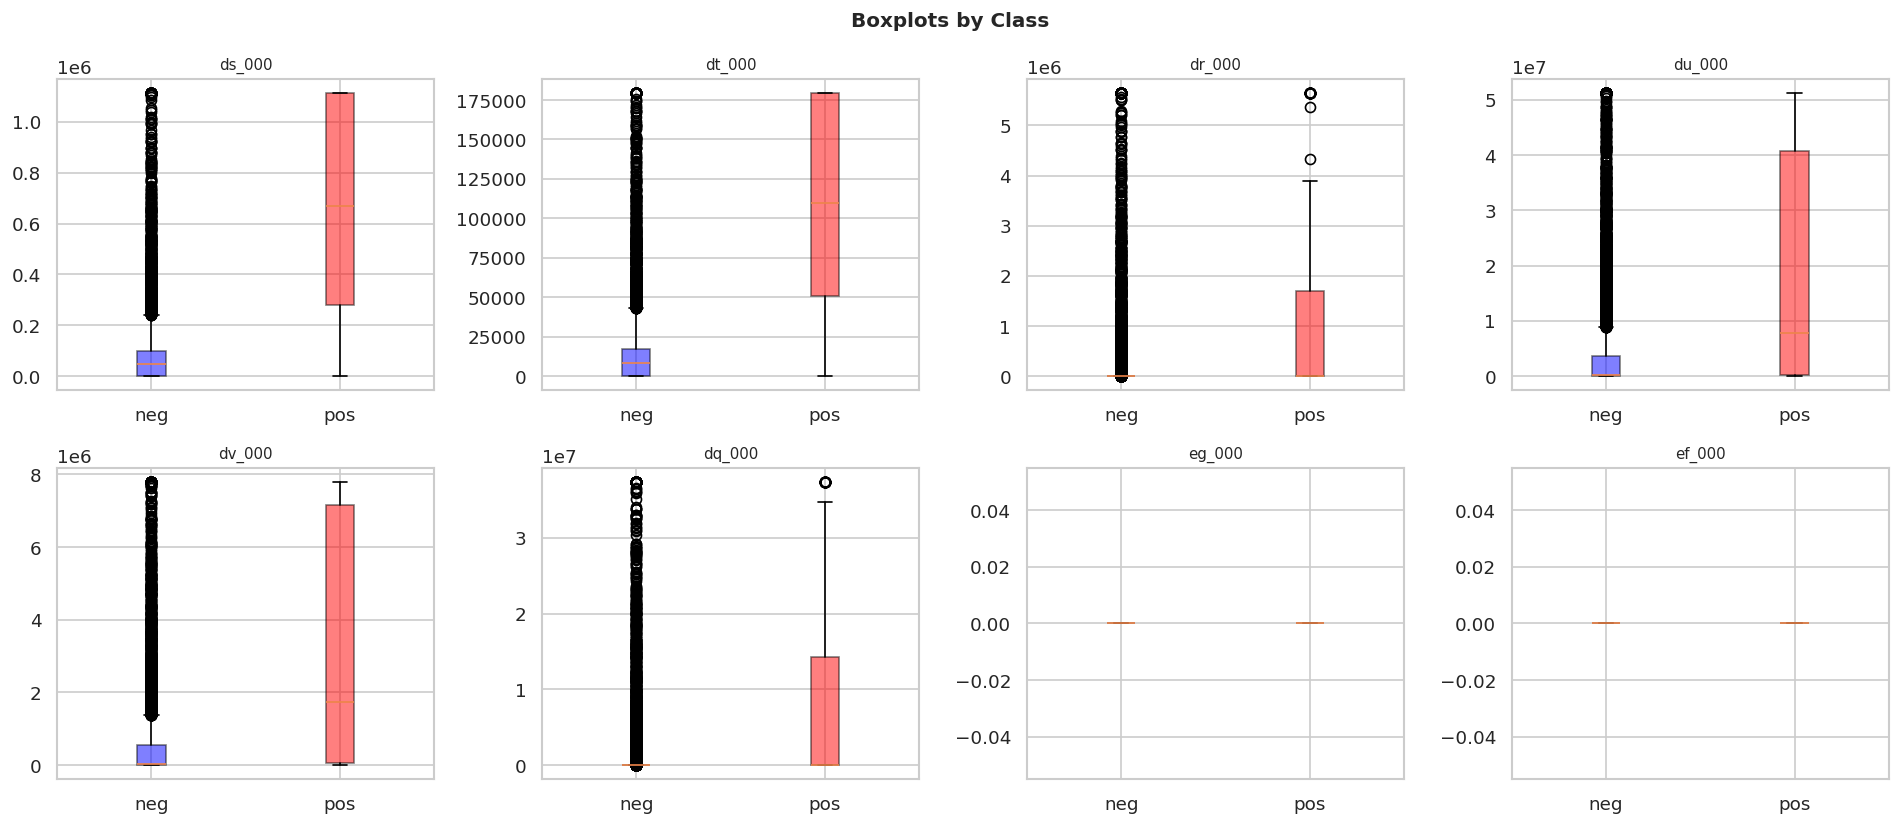

In [40]:
# Boxplots to visualize spread & outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(sample_features):
    data_to_plot = [
        df_train_raw[df_train_raw['class'] == 'neg'][col].dropna().clip(upper=df_train_raw[col].quantile(0.99)),
        df_train_raw[df_train_raw['class'] == 'pos'][col].dropna().clip(upper=df_train_raw[col].quantile(0.99))
    ]
    bp = axes[i].boxplot(data_to_plot, labels=['neg', 'pos'], patch_artist=True,
                         boxprops=dict(facecolor='blue', alpha=0.5))
    bp['boxes'][1].set(facecolor='red', alpha=0.5)
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplots by Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap

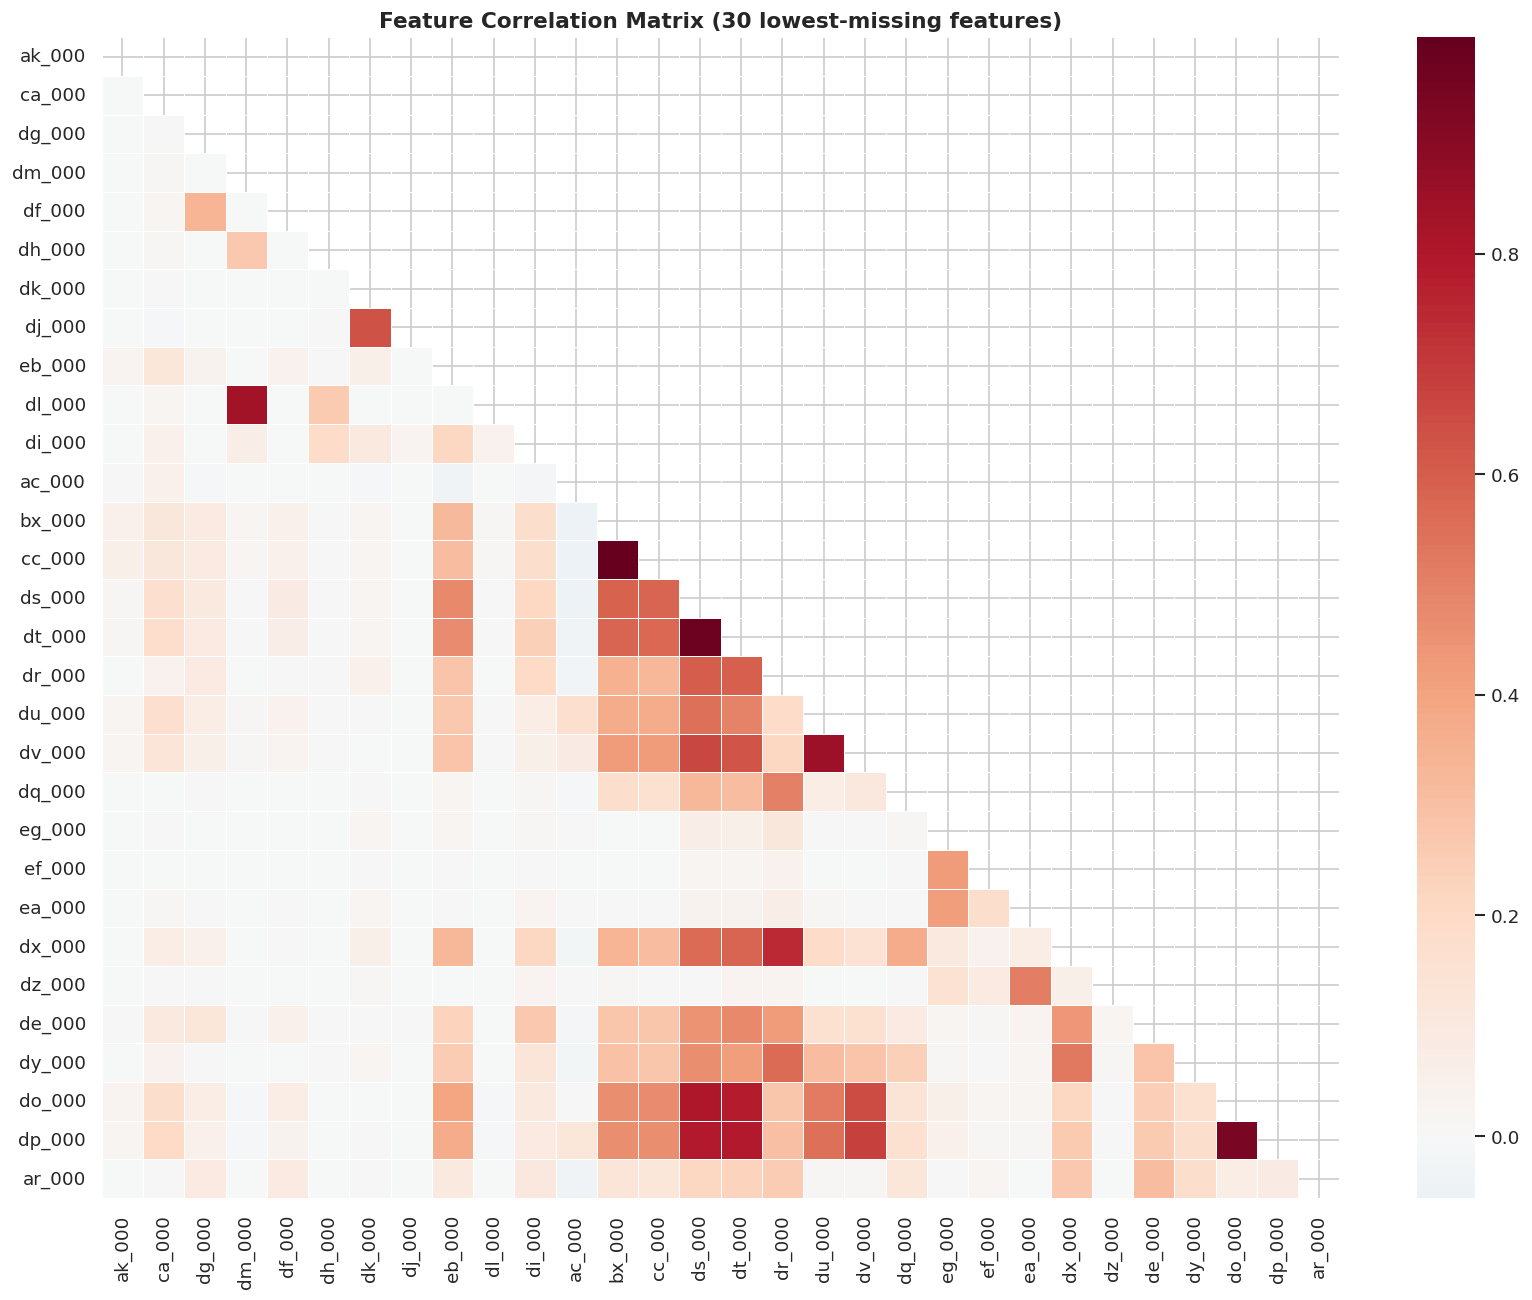

Highly correlated pairs: 3
  bx_000  <->  cc_000 :  r = 0.996
  ds_000  <->  dt_000 :  r = 0.972
  do_000  <->  dp_000 :  r = 0.944


In [41]:
# Computing correlations on a sample of 30 features with <10% missing
good_features = miss_pct[miss_pct < 10].index[:30].tolist()
corr_df = df_train_raw[good_features].copy()
corr_df = corr_df.fillna(corr_df.median())
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix (30 lowest-missing features)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
#Finds correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              round(corr_matrix.iloc[i, j], 3)))
print(f"Highly correlated pairs: {len(high_corr)}")
for pair in high_corr[:10]:
    print(f"  {pair[0]}  <->  {pair[1]} :  r = {pair[2]}")

# Data Preprocessing & Feature Engineering


In [42]:
# Encode labels
# Converts string labels ('pos', 'neg') to binary integers
le = LabelEncoder()
y_train = le.fit_transform(df_train_raw['class'])
y_test  = le.transform(df_test_raw['class'])
print(f"y_train: {y_train.sum()} positives out of {len(y_train)}")
print(f"y_test:  {y_test.sum()} positives out of {len(y_test)}")

y_train: 267 positives out of 14070
y_test:  375 positives out of 16000


In [43]:
# Drop high-missingness features
X_train_raw = df_train_raw.drop('class', axis=1)
X_test_raw  = df_test_raw.drop('class', axis=1)
miss_rate = X_train_raw.isnull().mean()
cols_to_drop = miss_rate[miss_rate > 0.80].index.tolist()
print(f"Dropping {len(cols_to_drop)} features with >80% missing rate:")
print(cols_to_drop)
X_train_filtered = X_train_raw.drop(columns=cols_to_drop)
X_test_filtered  = X_test_raw.drop(columns=cols_to_drop)
print(f"\nFeatures remaining: {X_train_filtered.shape[1]}")

Dropping 2 features with >80% missing rate:
['bq_000', 'br_000']

Features remaining: 168


In [44]:
#Build shared preprocessing pipeline
from sklearn.pipeline import Pipeline
preproc_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
X_train_prep = preproc_pipe.fit_transform(X_train_filtered)
X_test_prep  = preproc_pipe.transform(X_test_filtered)

print(f"Preprocessed training shape: {X_train_prep.shape}")
print(f"Preprocessed test shape    : {X_test_prep.shape}")
print("\nSample mean after scaling:")
print(X_train_prep[:, :5].mean(axis=0).round(4))

Preprocessed training shape: (14070, 168)
Preprocessed test shape    : (16000, 168)

Sample mean after scaling:
[ 0.  0.  0.  0. -0.]


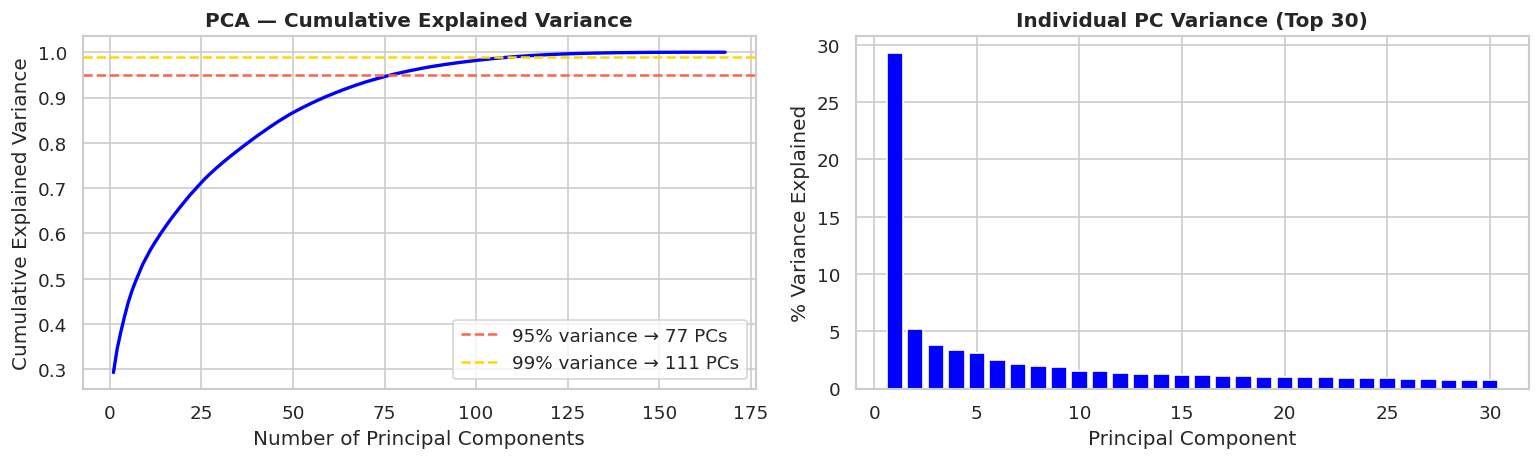


Original features: 168
PCs to retain 95% variance: 77  (45.8% of original)
PCs to retain 99% variance: 111  (66.1% of original)


In [45]:
# Dimensionality Reduction Analysis
pca_analysis = PCA(random_state=RANDOM_STATE)
pca_analysis.fit(X_train_prep)

cumvar = np.cumsum(pca_analysis.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_99   = np.argmax(cumvar >= 0.99) + 1
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(cumvar)+1), cumvar, color='blue', lw=2)
axes[0].axhline(0.95, color='tomato', linestyle='--', label=f'95% variance → {n_95} PCs')
axes[0].axhline(0.99, color='gold',   linestyle='--', label=f'99% variance → {n_99} PCs')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA — Cumulative Explained Variance', fontweight='bold')
axes[0].legend()
axes[1].bar(range(1, 31), pca_analysis.explained_variance_ratio_[:30]*100, color='blue')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('% Variance Explained')
axes[1].set_title('Individual PC Variance (Top 30)', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\nOriginal features: {X_train_prep.shape[1]}")
print(f"PCs to retain 95% variance: {n_95}  ({n_95/X_train_prep.shape[1]*100:.1f}% of original)")
print(f"PCs to retain 99% variance: {n_99}  ({n_99/X_train_prep.shape[1]*100:.1f}% of original)")

In [46]:
# \Apply PCA (95% variance) for PCA-based models\
pca = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca  = pca.transform(X_test_prep)
print(f"PCA reduced dimensions: {X_train_prep.shape[1]} to {X_train_pca.shape[1]}")

PCA reduced dimensions: 168 to 77


# Metric Justification

I evaluate all models using three primary metrics: Recall (Sensitivity) , F1-Score, andROC-AUC


In [47]:
#Helper: evaluate a fitted model
def evaluate_model(name, model, X_test, y_test, use_proba=True):
    """Return a metrics dict for a fitted model."""
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    if use_proba and hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = 10 * fp + 500 * fn

    return {
        'Model'     : name,
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_score),
        'Precision' : precision_score(y_test, y_pred),
        'Accuracy'  : (tp + tn) / (tp + tn + fp + fn),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Domain Cost': cost,
        'y_pred': y_pred,
        'y_score': y_score
    }
# Accumulate results across models
results = []

# Model Training, Tuning and Comparison


In [48]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
# Positive class weight for imbalanced learning
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale positive weight: {pos_weight:.1f}")

Scale positive weight: 51.7


## Model 1: Logistic Regression

In [49]:
print("Training Logistic Regression...")

lr_param_dist = {
    'C'      : [0.001, 0.01, 0.1, 1, 10],
    'solver' : ['lbfgs', 'saga'],
    'max_iter': [500]
}
# Base model to automatically adjust for class imbalance.
lr_base = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
lr_search = RandomizedSearchCV(
    lr_base, lr_param_dist, n_iter=10,
    scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
# Use PCA features for linear model
lr_search.fit(X_train_pca, y_train)

best_lr = lr_search.best_estimator_
print(f"Best params: {lr_search.best_params_}")
print(f"CV F1: {lr_search.best_score_:.4f}")
lr_result = evaluate_model('Logistic Regression', best_lr, X_test_pca, y_test)
results.append(lr_result)
print(f"\nTest Set Results:")
print(f"  Recall:      {lr_result['Recall']:.4f}")
print(f"  F1-Score:    {lr_result['F1-Score']:.4f}")
print(f"  ROC-AUC:     {lr_result['ROC-AUC']:.4f}")
print(f"  Domain Cost: {lr_result['Domain Cost']:,}")

Training Logistic Regression...
Best params: {'solver': 'lbfgs', 'max_iter': 500, 'C': 0.1}
CV F1: 0.5575

Test Set Results:
  Recall:      0.8933
  F1-Score:    0.6091
  ROC-AUC:     0.9615
  Domain Cost: 23,900


## Model 2: K-Nearest Neighbors

In [50]:
print("Training K-Nearest Neighbors (using PCA-reduced data for speed)...")

# Use PCA-reduced data for KNN (distance-based, benefits from dimensionality reduction)
knn_param_dist = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier(n_jobs=-1)
knn_search = RandomizedSearchCV(
    knn_base, knn_param_dist, n_iter=10,
    scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
knn_search.fit(X_train_pca, y_train)

best_knn = knn_search.best_estimator_
print(f"Best params: {knn_search.best_params_}")
print(f"CV F1: {knn_search.best_score_:.4f}")
knn_result = evaluate_model('K-Nearest Neighbors', best_knn, X_test_pca, y_test)
results.append(knn_result)
print(f"\nTest Set Results:")
print(f"  Recall:      {knn_result['Recall']:.4f}")
print(f"  F1-Score:    {knn_result['F1-Score']:.4f}")
print(f"  ROC-AUC:     {knn_result['ROC-AUC']:.4f}")
print(f"  Domain Cost: {knn_result['Domain Cost']:,}")

Training K-Nearest Neighbors (using PCA-reduced data for speed)...
Best params: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}
CV F1: 0.6393

Test Set Results:
  Recall:      0.5600
  F1-Score:    0.6635
  ROC-AUC:     0.8581
  Domain Cost: 82,980


## Model 3: Decision Tree

In [51]:
print("Training Decision Tree...")
dt_param_dist = {
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf' : [1, 5, 10, 20],
    'criterion'        : ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_search = RandomizedSearchCV(
    dt_base, dt_param_dist, n_iter=15,
    scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
dt_search.fit(X_train_prep, y_train)
best_dt = dt_search.best_estimator_
print(f"Best params: {dt_search.best_params_}")
print(f"CV F1: {dt_search.best_score_:.4f}")
dt_result = evaluate_model('Decision Tree', best_dt, X_test_prep, y_test)
results.append(dt_result)
print(f"\nTest Set Results:")
print(f"  Recall:      {dt_result['Recall']:.4f}")
print(f"  F1-Score:    {dt_result['F1-Score']:.4f}")
print(f"  ROC-AUC:     {dt_result['ROC-AUC']:.4f}")
print(f"  Domain Cost: {dt_result['Domain Cost']:,}")

Training Decision Tree...
Best params: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10, 'criterion': 'entropy'}
CV F1: 0.5235

Test Set Results:
  Recall:      0.8133
  F1-Score:    0.6131
  ROC-AUC:     0.9004
  Domain Cost: 38,150


## Model 4:Random Forest

In [52]:
print("Training Random Forest...")

rf_param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_search = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=15,
    scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_prep, y_train)
best_rf = rf_search.best_estimator_
print(f"\nBest params: {rf_search.best_params_}")
print(f"CV F1: {rf_search.best_score_:.4f}")

rf_result = evaluate_model('Random Forest', best_rf, X_test_prep, y_test)
results.append(rf_result)
print(f"\nTest Set Results:")
print(f"  Recall:      {rf_result['Recall']:.4f}")
print(f"  F1-Score:    {rf_result['F1-Score']:.4f}")
print(f"  ROC-AUC:     {rf_result['ROC-AUC']:.4f}")
print(f"  Domain Cost: {rf_result['Domain Cost']:,}")

Training Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
CV F1: 0.6988

Test Set Results:
  Recall:      0.7573
  F1-Score:    0.7634
  ROC-AUC:     0.9932
  Domain Cost: 46,350


## Model 5: XGBoost

In [53]:
if XGBOOST_AVAILABLE:
    print("Training XGBoost...")
    xgb_param_dist = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [3, 5, 7, 9],
        'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
        'subsample'       : [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    }
    xgb_base = XGBClassifier(
        scale_pos_weight=pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        n_jobs=-1
    )
    xgb_search = RandomizedSearchCV(xgb_base, xgb_param_dist, n_iter=15,
        scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )
    xgb_search.fit(X_train_prep, y_train)

    best_xgb = xgb_search.best_estimator_
    print(f"\nBest params: {xgb_search.best_params_}")
    print(f"CV F1: {xgb_search.best_score_:.4f}")

    xgb_result = evaluate_model('XGBoost', best_xgb, X_test_prep, y_test)
    results.append(xgb_result)
    print(f"\nTest Set Results:")
    print(f"  Recall:      {xgb_result['Recall']:.4f}")
    print(f"  F1-Score:    {xgb_result['F1-Score']:.4f}")
    print(f"  ROC-AUC:     {xgb_result['ROC-AUC']:.4f}")
    print(f"  Domain Cost: {xgb_result['Domain Cost']:,}")
else:
    print("XGBoost not available, use GradientBoostingClassifier as substitute.")

    gb_param_dist = {
        'n_estimators' : [100, 200],
        'max_depth'    : [3, 5],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample'    : [0.7, 1.0]
    }
    gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)
    gb_search = RandomizedSearchCV(
        gb_base, gb_param_dist, n_iter=10,
        scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )
    gb_search.fit(X_train_prep, y_train)
    best_xgb = gb_search.best_estimator_
    xgb_result = evaluate_model('Gradient Boosting', best_xgb, X_test_prep, y_test)
    xgb_result['Model'] = 'Gradient Boosting, XGB substitute'
    results.append(xgb_result)
    print(f"Test Recall: {xgb_result['Recall']:.4f}  |  F1: {xgb_result['F1-Score']:.4f}")

Training XGBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
CV F1: 0.7549

Test Set Results:
  Recall:      0.7893
  F1-Score:    0.8222
  ROC-AUC:     0.9946
  Domain Cost: 39,990


## Model 6:Linear SVM

In [54]:
print("Training Linear SVM...")
svm_param_dist = {
    'C'      : [0.001, 0.01, 0.1, 1, 10],
    'max_iter': [2000]
}

svm_base = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, dual=True)
svm_search = RandomizedSearchCV(
    svm_base, svm_param_dist, n_iter=5,
    scoring='f1', cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
svm_search.fit(X_train_pca, y_train)

best_svm = svm_search.best_estimator_
print(f"Best params: {svm_search.best_params_}")
print(f"CV F1: {svm_search.best_score_:.4f}")

# LinearSVC uses decision_function for scoring
svm_result = evaluate_model('Linear SVM', best_svm, X_test_pca, y_test, use_proba=False)
results.append(svm_result)
print(f"\nTest Set Results:")
print(f"  Recall:      {svm_result['Recall']:.4f}")
print(f"  F1-Score:    {svm_result['F1-Score']:.4f}")
print(f"  ROC-AUC:     {svm_result['ROC-AUC']:.4f}")
print(f"  Domain Cost: {svm_result['Domain Cost']:,}")

Training Linear SVM...
Best params: {'max_iter': 2000, 'C': 1}
CV F1: 0.6227

Test Set Results:
  Recall:      0.7867
  F1-Score:    0.6991
  ROC-AUC:     0.9161
  Domain Cost: 41,740


# Model Evaluation and Comparison

## Summary Leaderboard

In [55]:
# Build results table
leaderboard_data = [
    {
        'Model'      : r['Model'],
        'Recall'     : round(r['Recall'], 4),
        'F1-Score'   : round(r['F1-Score'], 4),
        'ROC-AUC'    : round(r['ROC-AUC'], 4),
        'Precision'  : round(r['Precision'], 4),
        'Accuracy'   : round(r['Accuracy'], 4),
        'TP'         : r['TP'],
        'FP'         : r['FP'],
        'FN'         : r['FN'],
        'Domain Cost': r['Domain Cost']
    } for r in results
]

df_results = pd.DataFrame(leaderboard_data).sort_values('Domain Cost')
df_results = df_results.reset_index(drop=True)

# Style the table
display(df_results.style
    .background_gradient(subset=['Recall', 'F1-Score', 'ROC-AUC'], cmap='Greens')
    .background_gradient(subset=['Domain Cost'], cmap='Reds_r')
    .format({
        'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}',
        'Precision': '{:.4f}', 'Accuracy': '{:.4f}', 'Domain Cost': '{:,}'
    })
    .set_caption('Model Comparison — Sorted by Domain Cost (lower is better)')
)

,Model,Recall,F1-Score,ROC-AUC,Precision,Accuracy,TP,FP,FN,Domain Cost
0,Logistic Regression,0.8933,0.6091,0.9615,0.4621,0.9731,335,390,40,"23,900"
1,Decision Tree,0.8133,0.6131,0.9004,0.4919,0.9759,305,315,70,"38,150"
2,XGBoost,0.7893,0.8222,0.9946,0.8580,0.9920,296,49,79,"39,990"
3,Linear SVM,0.7867,0.6991,0.9161,0.6290,0.9841,295,174,80,"41,740"
4,Random Forest,0.7573,0.7634,0.9932,0.7696,0.9890,284,85,91,"46,350"
5,K-Nearest Neighbors,0.5600,0.6635,0.8581,0.8140,0.9867,210,48,165,"82,980"


##Bar Chart Comparison

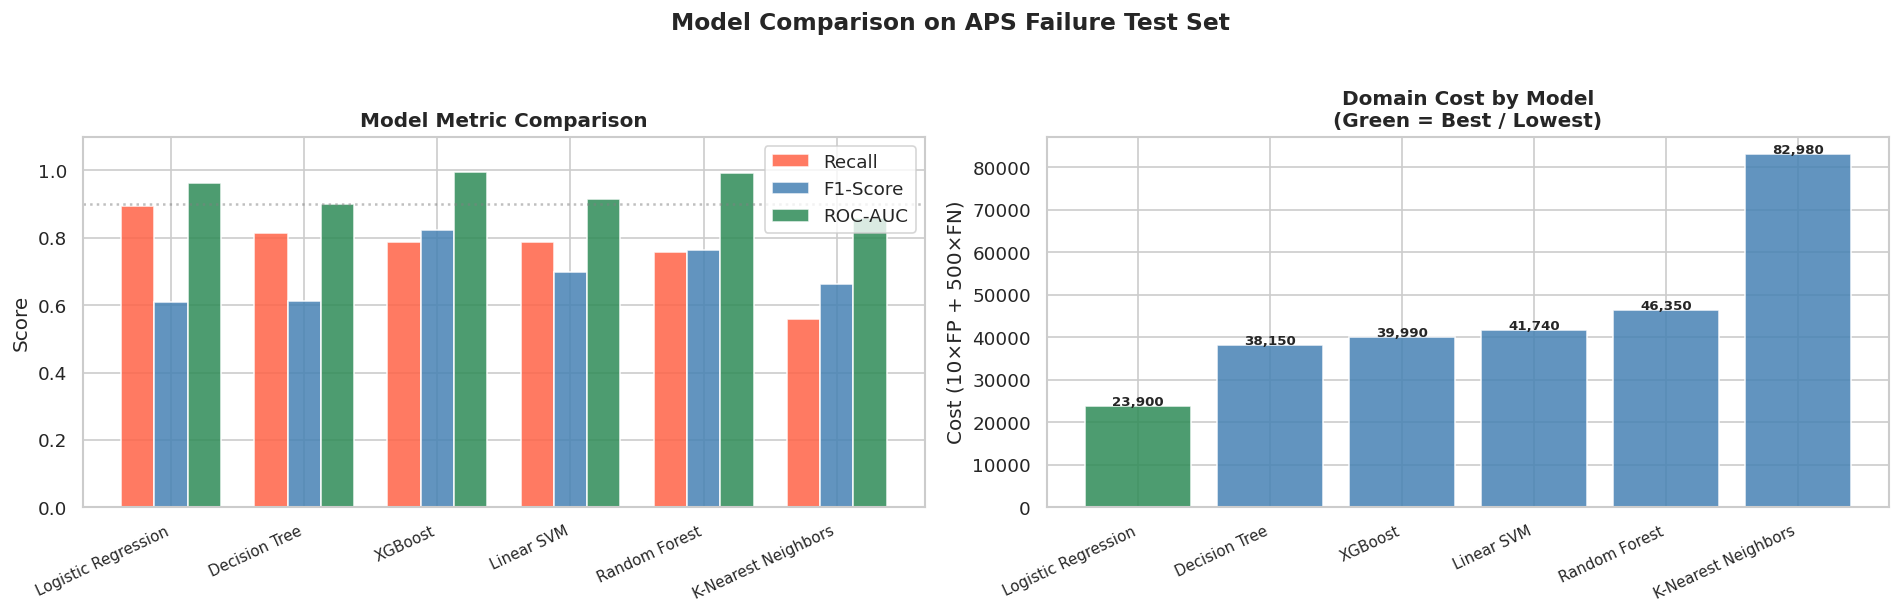

In [65]:
model_names  = df_results['Model'].tolist()
recalls      = df_results['Recall'].tolist()
f1s          = df_results['F1-Score'].tolist()
aucs         = df_results['ROC-AUC'].tolist()
costs        = df_results['Domain Cost'].tolist()

x     = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Left: Metric comparison
axes[0].bar(x - width, recalls, width, label='Recall',   color='tomato',    alpha=0.85)
axes[0].bar(x,          f1s,    width, label='F1-Score', color='steelblue', alpha=0.85)
axes[0].bar(x + width,  aucs,   width, label='ROC-AUC',  color='seagreen',  alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Metric Comparison', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.9, color='gray', linestyle=':', alpha=0.5)

# Right: Domain cost (lower = better)
colors = ['seagreen' if c == min(costs) else 'steelblue' for c in costs]
axes[1].bar(model_names, costs, color=colors, alpha=0.85)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Cost (10×FP + 500×FN)')
axes[1].set_title('Domain Cost by Model\n(Green = Best / Lowest)', fontweight='bold')
for i, v in enumerate(costs):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Model Comparison on APS Failure Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Confusion Matrices

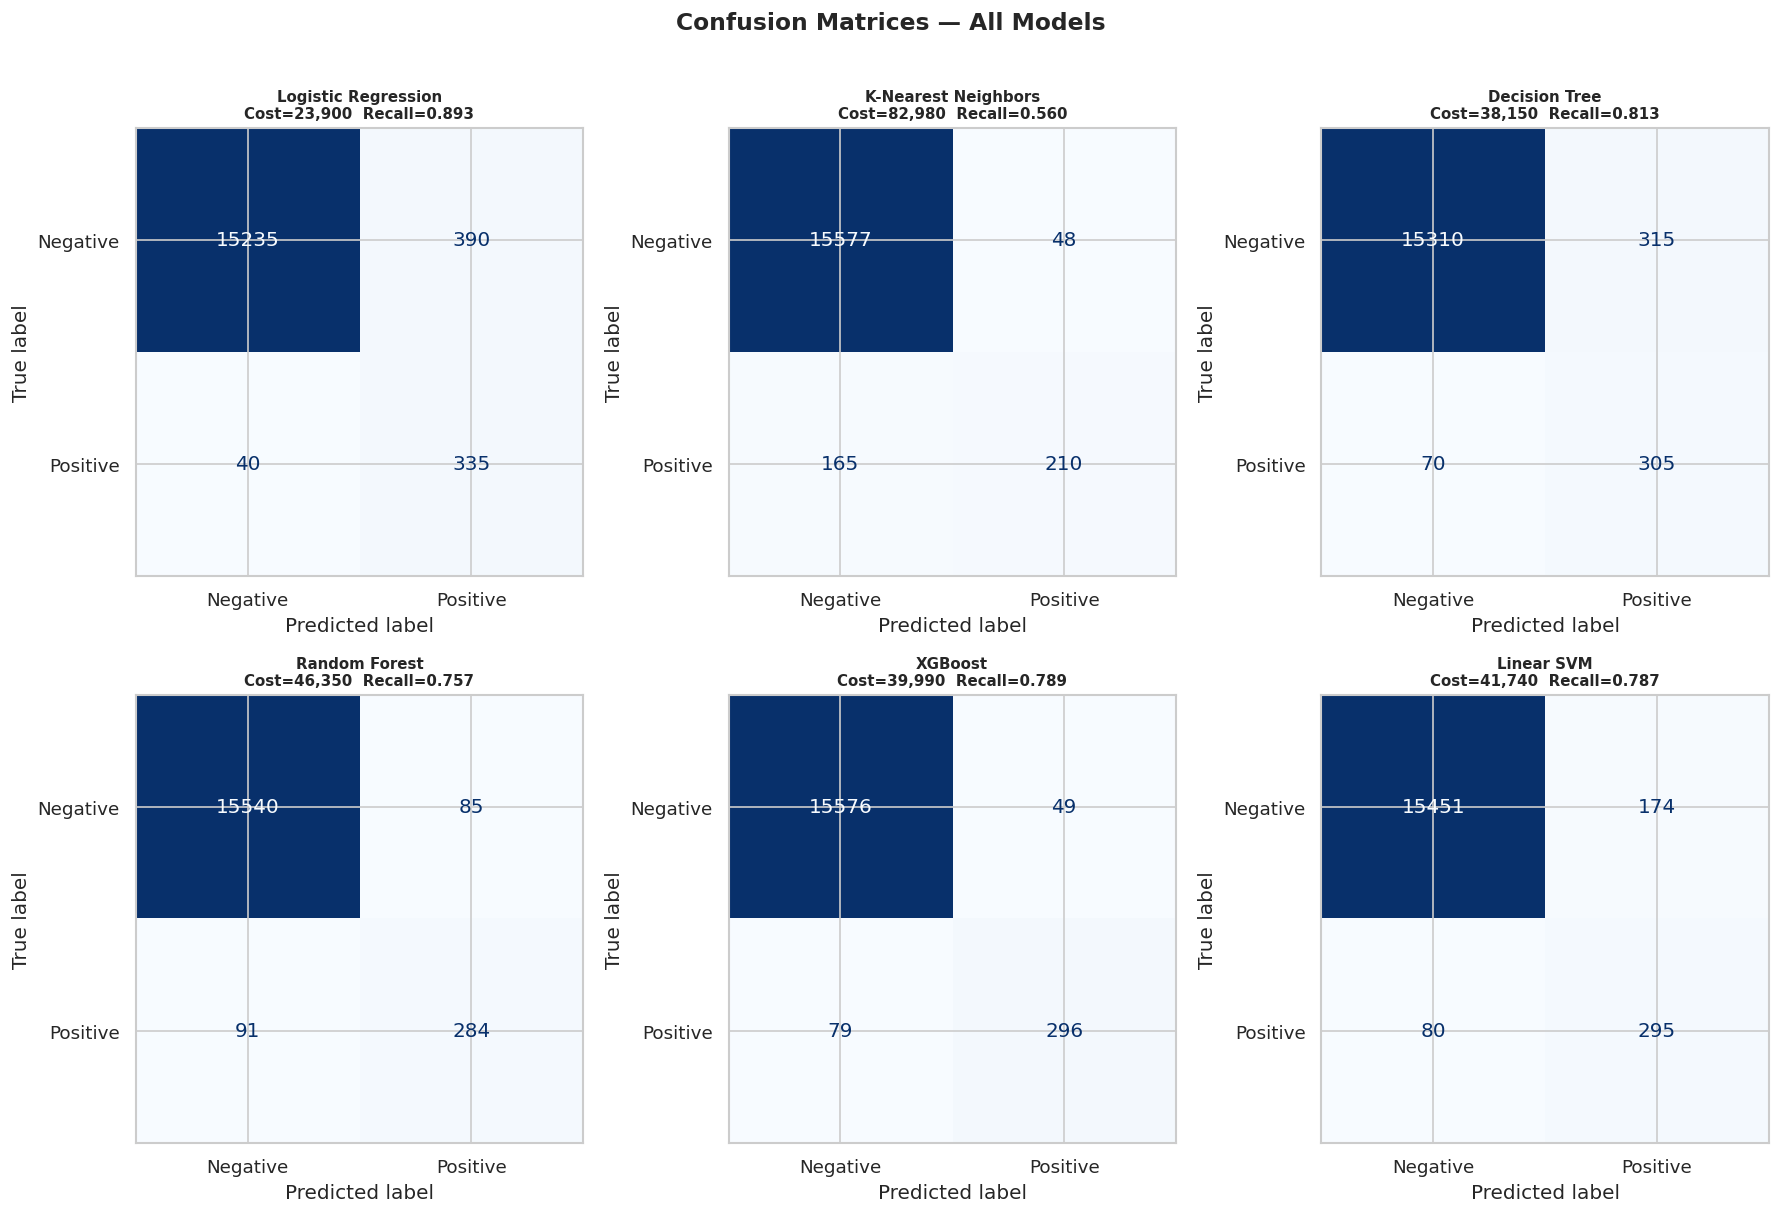

In [66]:
n_models = len(results)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()
for i, r in enumerate(results):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Negative', 'Positive'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(
        f"{r['Model']}\nCost={r['Domain Cost']:,}  Recall={r['Recall']:.3f}",
        fontsize=9, fontweight='bold'
    )

# Hidong unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## ROC Curves

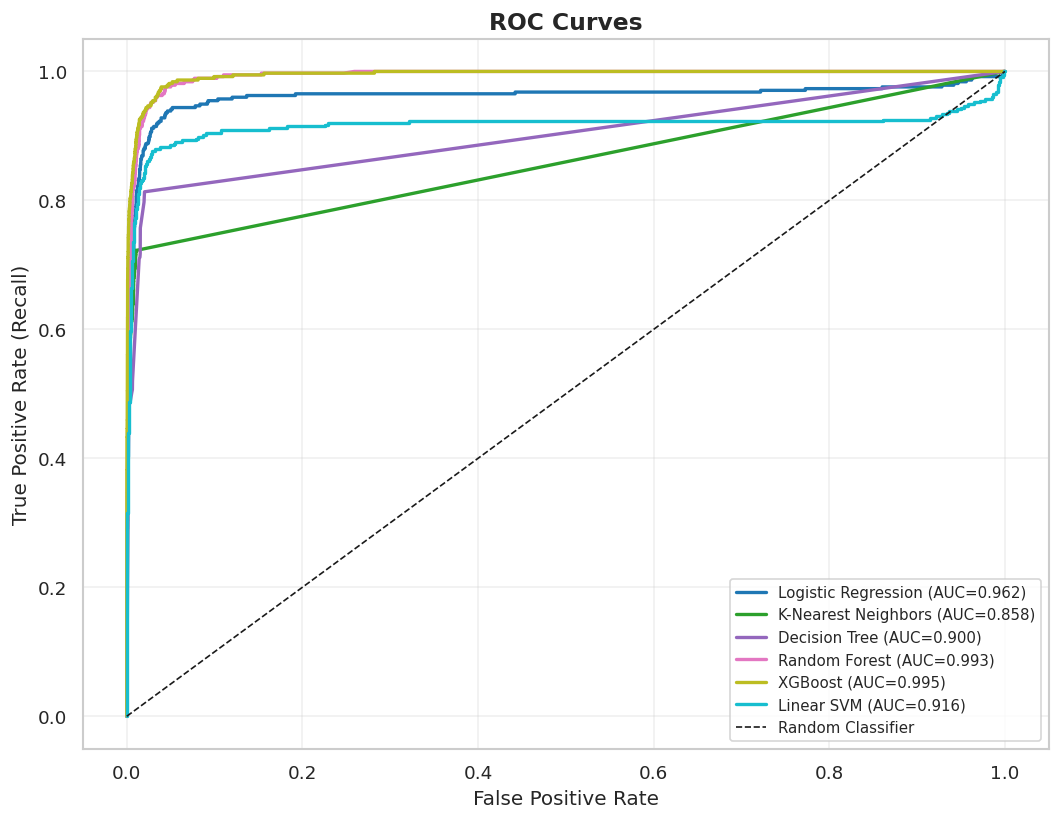

In [67]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for r, color in zip(results, colors):
    try:
        fpr, tpr, _ = roc_curve(y_test, r['y_score'])
        ax.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})",
                color=color, lw=2)
    except Exception:
        pass

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Precision–Recall Curves

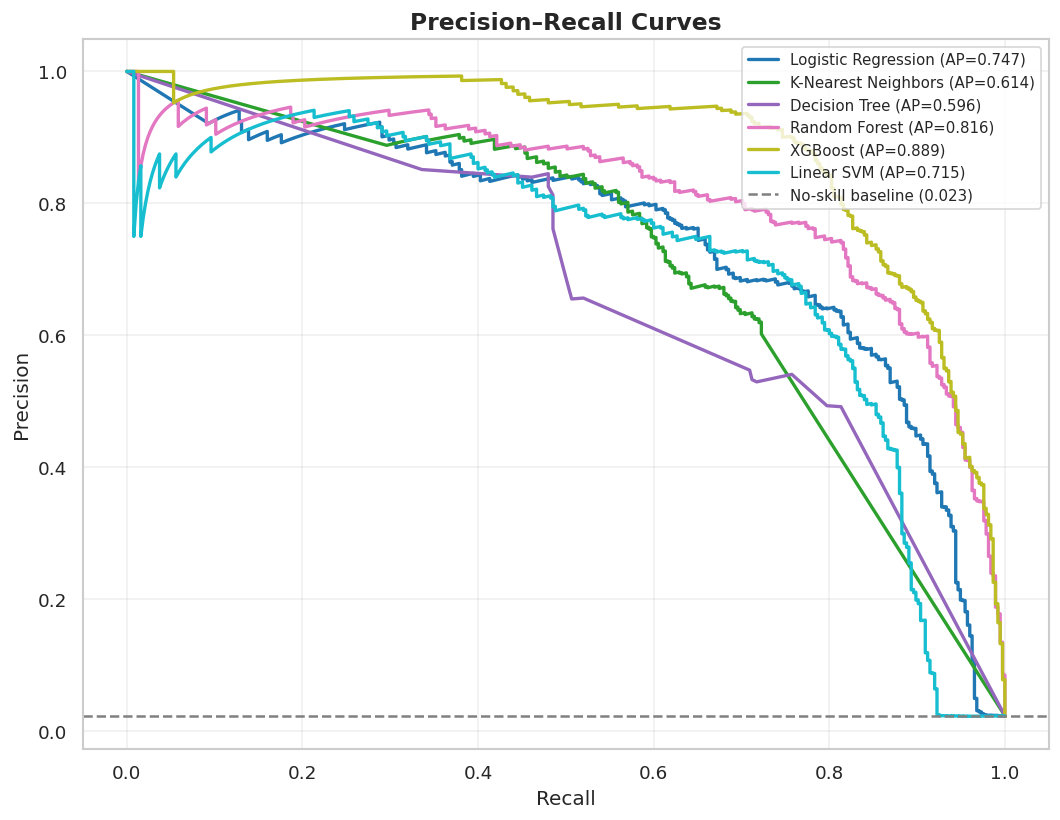

In [68]:
fig, ax = plt.subplots(figsize=(9, 7))
for r, color in zip(results, colors):
    try:
        prec, rec, _ = precision_recall_curve(y_test, r['y_score'])
        ap = average_precision_score(y_test, r['y_score'])
        ax.plot(rec, prec, label=f"{r['Model']} (AP={ap:.3f})",
                color=color, lw=2)
    except Exception:
        pass
baseline = y_test.sum() / len(y_test)
ax.axhline(baseline, color='gray', linestyle='--', label=f'No-skill baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision–Recall Curves', fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Feature Importance (Random Forest)

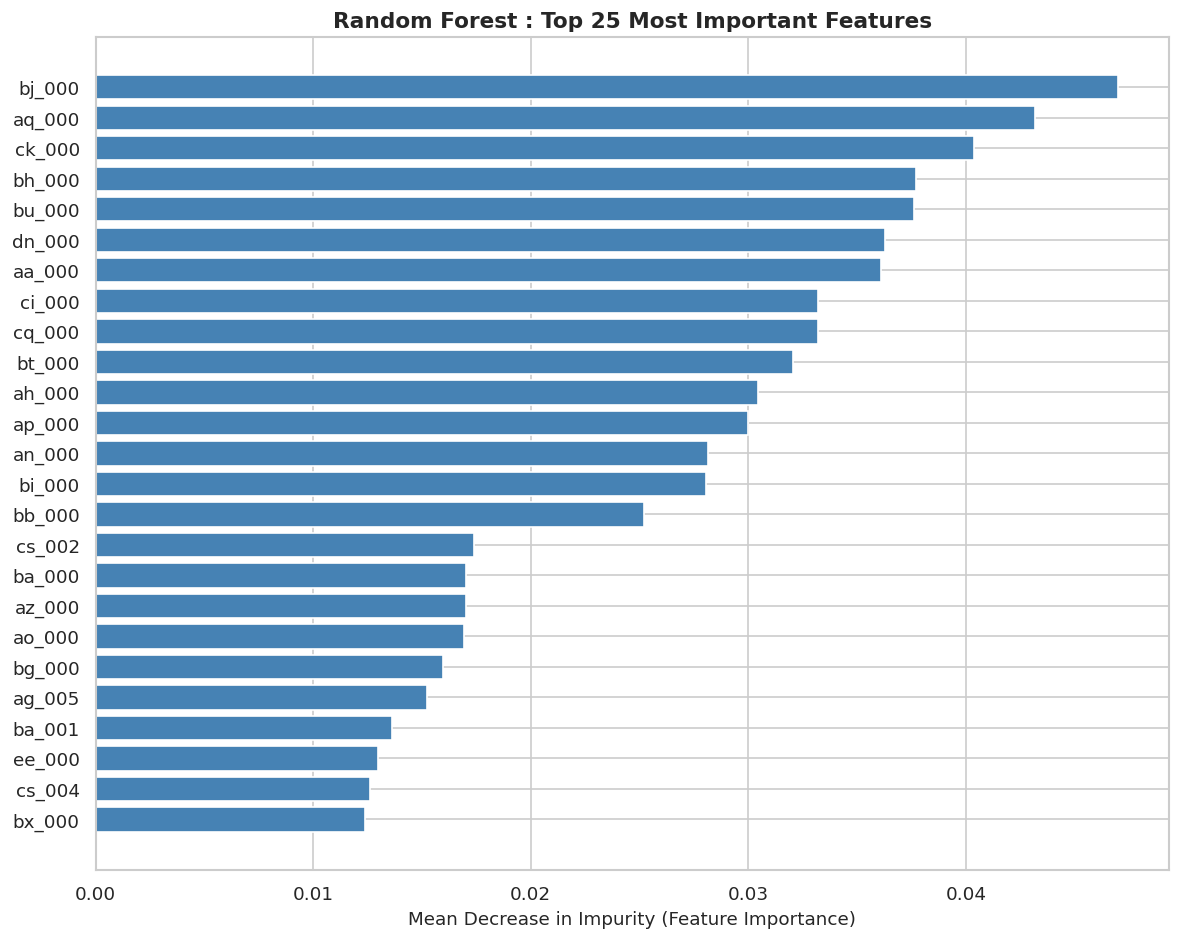

Top 10 features by importance:
feature  importance
 bj_000    0.046975
 aq_000    0.043162
 ck_000    0.040353
 bh_000    0.037727
 bu_000    0.037616
 dn_000    0.036297
 aa_000    0.036119
 ci_000    0.033217
 cq_000    0.033213
 bt_000    0.032046


In [69]:
# Extract feature importances from the Random Forest
feature_names = X_train_filtered.columns.tolist()
importances   = best_rf.feature_importances_
feat_imp_df   = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df   = feat_imp_df.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=11)
ax.set_title('Random Forest : Top 25 Most Important Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 10 features by importance:")
print(feat_imp_df[['feature', 'importance']].head(10).to_string(index=False))

## Feature Importance (XGBoost)

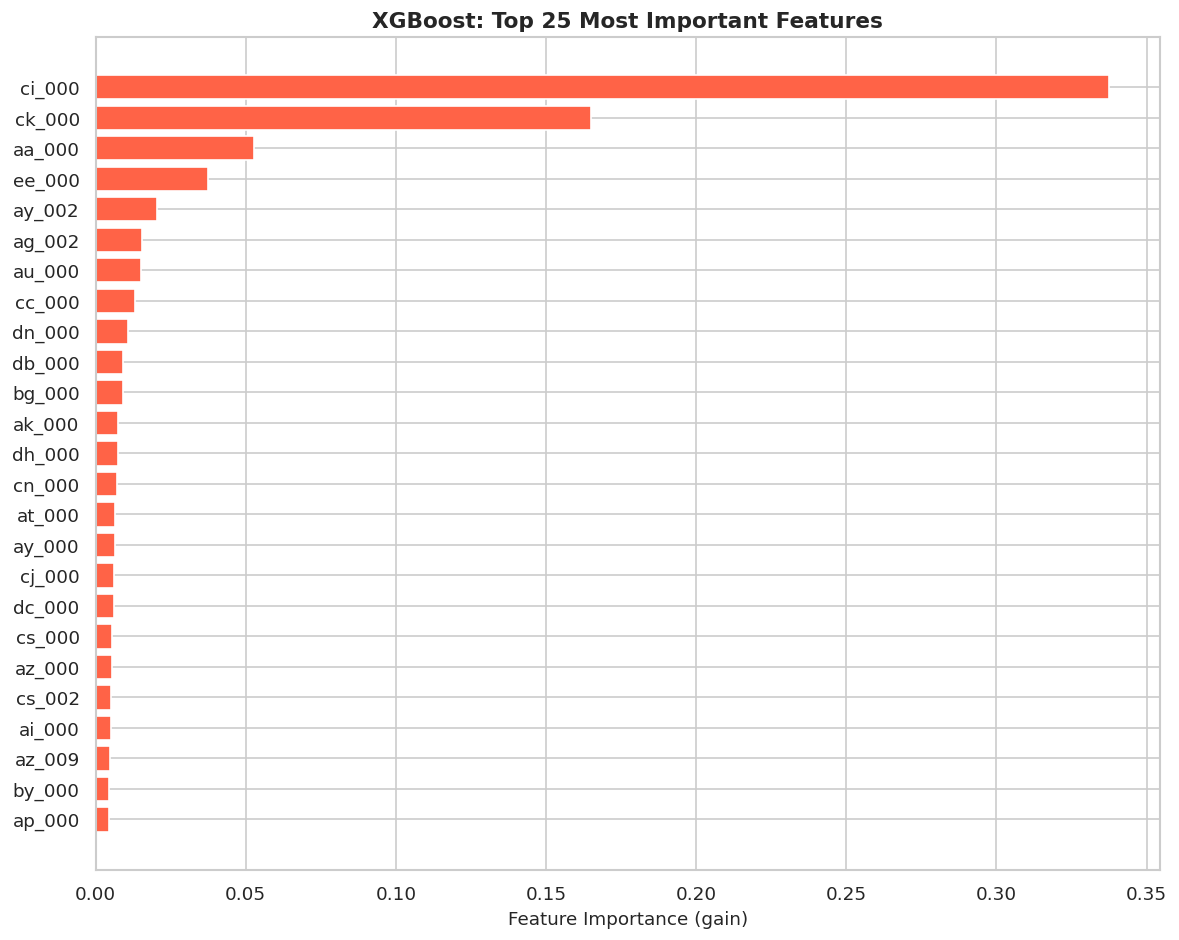


Features in BOTH RF and XGB top-10: 4
{'ck_000', 'aa_000', 'dn_000', 'ci_000'}


In [71]:
if XGBOOST_AVAILABLE:
    xgb_importances = best_xgb.feature_importances_
    xgb_feat_df = pd.DataFrame({'feature': feature_names, 'importance': xgb_importances})
    xgb_feat_df = xgb_feat_df.sort_values('importance', ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(xgb_feat_df['feature'][::-1], xgb_feat_df['importance'][::-1],
            color='tomato', edgecolor='white')
    ax.set_xlabel('Feature Importance (gain)', fontsize=11)
    ax.set_title('XGBoost: Top 25 Most Important Features', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Overlap with RF top features
    rf_top10  = set(feat_imp_df['feature'].head(10))
    xgb_top10 = set(xgb_feat_df['feature'].head(10))
    overlap   = rf_top10 & xgb_top10
    print(f"\nFeatures in BOTH RF and XGB top-10: {len(overlap)}")
    print(overlap)
else:
    print("XGBoost not available, skipping XGB feature importance.")

# Detailed Classification Reports

In [72]:
for r in results:
    print("=" * 55)
    print(f"  {r['Model']}")
    print("=" * 55)
    print(classification_report(y_test, r['y_pred'],
                                target_names=['Negative (non-APS)', 'Positive (APS failure)']))
    print(f"  Domain Cost: {r['Domain Cost']:,}  |  TP={r['TP']}  FP={r['FP']}  FN={r['FN']}  TN={r['TN']}")
    print()

  Logistic Regression
                        precision    recall  f1-score   support

    Negative (non-APS)       1.00      0.98      0.99     15625
Positive (APS failure)       0.46      0.89      0.61       375

              accuracy                           0.97     16000
             macro avg       0.73      0.93      0.80     16000
          weighted avg       0.98      0.97      0.98     16000

  Domain Cost: 23,900  |  TP=335  FP=390  FN=40  TN=15235

  K-Nearest Neighbors
                        precision    recall  f1-score   support

    Negative (non-APS)       0.99      1.00      0.99     15625
Positive (APS failure)       0.81      0.56      0.66       375

              accuracy                           0.99     16000
             macro avg       0.90      0.78      0.83     16000
          weighted avg       0.99      0.99      0.99     16000

  Domain Cost: 82,980  |  TP=210  FP=48  FN=165  TN=15577

  Decision Tree
                        precision    recall  f1-

#Final Analysis & Conclusion

## Best Model Selection

In [74]:
best_by_cost   = df_results.iloc[0]
best_by_recall = df_results.loc[df_results['Recall'].idxmax()]
best_by_f1     = df_results.loc[df_results['F1-Score'].idxmax()]
best_by_auc    = df_results.loc[df_results['ROC-AUC'].idxmax()]

print("╔══════════════════════════════════════════════════════════╗")
print("║                BEST MODEL SUMMARY                       ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║ Best Domain Cost : {best_by_cost['Model']:<35} ║")
print(f"║                    Cost={best_by_cost['Domain Cost']:,}                        ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║ Best Recall      : {best_by_recall['Model']:<35} ║")
print(f"║                    Recall={best_by_recall['Recall']:.4f}                    ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║ Best F1-Score    : {best_by_f1['Model']:<35} ║")
print(f"║                    F1={best_by_f1['F1-Score']:.4f}                       ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║ Best ROC-AUC     : {best_by_auc['Model']:<35} ║")
print(f"║                    AUC={best_by_auc['ROC-AUC']:.4f}                      ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║                BEST MODEL SUMMARY                       ║
╠══════════════════════════════════════════════════════════╣
║ Best Domain Cost : Logistic Regression                 ║
║                    Cost=23,900                        ║
╠══════════════════════════════════════════════════════════╣
║ Best Recall      : Logistic Regression                 ║
║                    Recall=0.8933                    ║
╠══════════════════════════════════════════════════════════╣
║ Best F1-Score    : XGBoost                             ║
║                    F1=0.8222                       ║
╠══════════════════════════════════════════════════════════╣
║ Best ROC-AUC     : XGBoost                             ║
║                    AUC=0.9946                      ║
╚══════════════════════════════════════════════════════════╝


In [75]:
#Final ranked leaderboard
print("\n" + "═"*70)
print(" FINAL MODEL LEADERBOARD (ranked by Domain Cost — lower is better)")
print("═"*70)
print(df_results[['Model', 'Recall', 'F1-Score', 'ROC-AUC', 'Domain Cost']].to_string(index=False))
print("═"*70)


══════════════════════════════════════════════════════════════════════
 FINAL MODEL LEADERBOARD (ranked by Domain Cost — lower is better)
══════════════════════════════════════════════════════════════════════
              Model  Recall  F1-Score  ROC-AUC  Domain Cost
Logistic Regression  0.8933    0.6091   0.9615        23900
      Decision Tree  0.8133    0.6131   0.9004        38150
            XGBoost  0.7893    0.8222   0.9946        39990
         Linear SVM  0.7867    0.6991   0.9161        41740
      Random Forest  0.7573    0.7634   0.9932        46350
K-Nearest Neighbors  0.5600    0.6635   0.8581        82980
══════════════════════════════════════════════════════════════════════
